<a href="https://colab.research.google.com/github/znagy101/california-housing-prediction/blob/main/california_housing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

california_dataset = fetch_california_housing(as_frame=True)
df = california_dataset.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


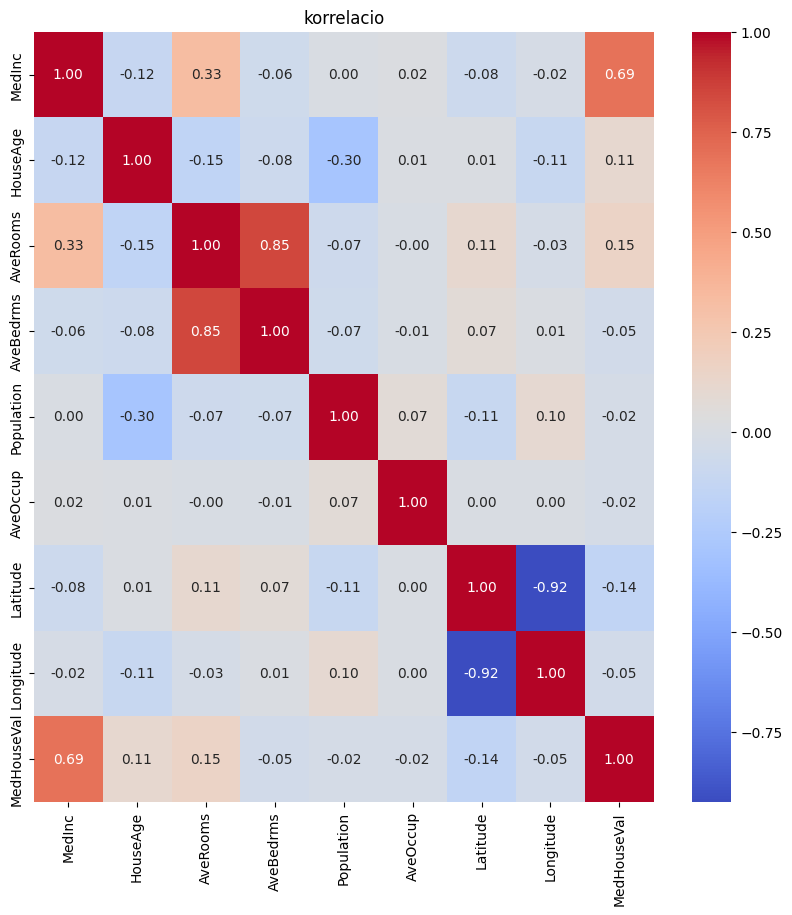

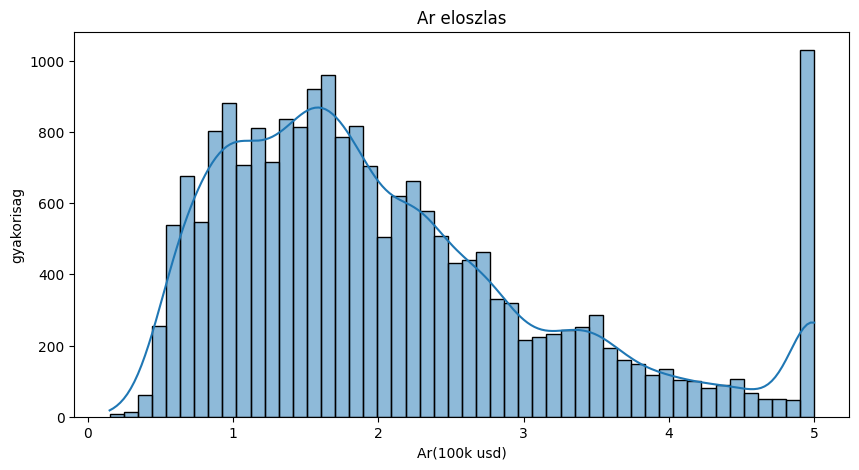

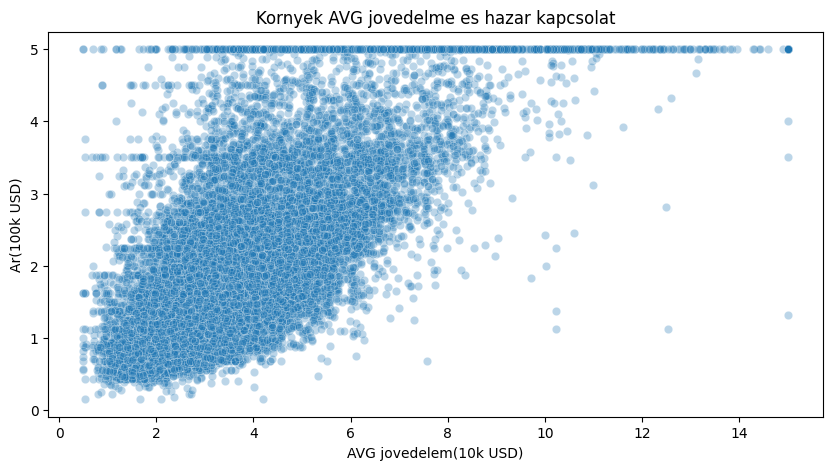

In [ ]:
import seaborn as sns
from sklearn.datasets import fetch_california_housing

df.info()
df.describe().round(3)

plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("korrelacio")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title("Ar eloszlas")
plt.xlabel("Ar(100k usd)")
plt.ylabel("gyakorisag")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.3)
plt.title("Kornyek AVG jovedelme es hazar kapcsolat")
plt.xlabel("AVG jovedelem(10k USD)")
plt.ylabel("Ar(100k USD)")
plt.show()



In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X=df.drop('MedHouseVal', axis=1)
Y=df['MedHouseVal']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("Tanito adatok merete ", X_train.shape)
print("Teszt adatok merete ", X_test.shape)

Tanito adatok merete  (16512, 8)
Teszt adatok merete  (4128, 8)


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, Y_train)
lin_reg_predictions = lin_reg.predict(X_test_scaled)

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
rf_reg.fit(X_train_scaled, Y_train)
rf_reg_predictions = rf_reg.predict(X_test_scaled)

In [56]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, Y_test, Y_pred):
  mae = mean_absolute_error(Y_test, Y_pred)
  rmse = np.sqrt(mean_squared_error(Y_test, Y_pred) )
  r2 = r2_score(Y_test, Y_pred)
  print(name)
  print("MAE: ", round(mae, 3))
  print("RMSE: ", round(rmse, 3))
  print("R2: ", round(r2, 3))

evaluate_model("Linearis Regresszio", Y_test, lin_reg_predictions)
print('\n')
evaluate_model("Random Forest Regresszio", Y_test, rf_reg_predictions)



Linearis Regresszio
MAE:  0.535
RMSE:  0.734
R2:  0.589


Random Forest Regresszio
MAE:  0.563
RMSE:  0.796
R2:  0.517


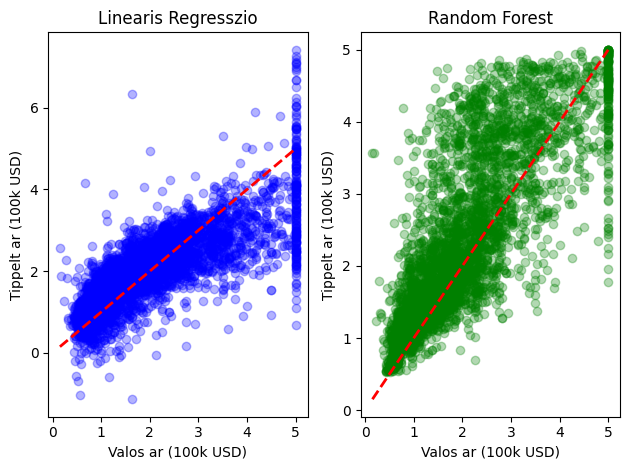

In [59]:
plt.subplot(1, 2, 1)
plt.scatter(Y_test, lin_reg_predictions, alpha=0.3, color='blue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.title("Linearis Regresszio")
plt.xlabel("Valos ar (100k USD)")
plt.ylabel("Tippelt ar (100k USD)")


plt.subplot(1, 2, 2)
plt.scatter(Y_test, rf_reg_predictions, alpha=0.3, color='green')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.title("Random Forest")
plt.xlabel("Valos ar (100k USD)")
plt.ylabel("Tippelt ar (100k USD)")

plt.tight_layout()
plt.show()